In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Crop Yeild Data.csv")

In [3]:
df = df.drop(["Area", "Production"], axis=1)

In [4]:
df = df.drop("Crop_Year", axis=1)

In [5]:
df = df.drop(["Max_Temperature", "Min_Temperature"], axis=1)

In [6]:
df["Yield"] = np.log1p(df["Yield"])

In [7]:
X = df.drop("Yield", axis=1)
y = df["Yield"]

In [8]:
print("Max y after log:", y.max()) 

Max y after log: 9.957312639231036


In [9]:
X = pd.get_dummies(X, columns=["Crop", "Season", "State"], drop_first=True)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)

print("Max predicted log:", y_pred_log.max())

Max predicted log: 9.453393740636345


In [10]:
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

In [11]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test_original, y_pred)
mae = mean_absolute_error(y_test_original, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.900461192616268
MAE: 13.520277686168523
RMSE: 282.4083200008977


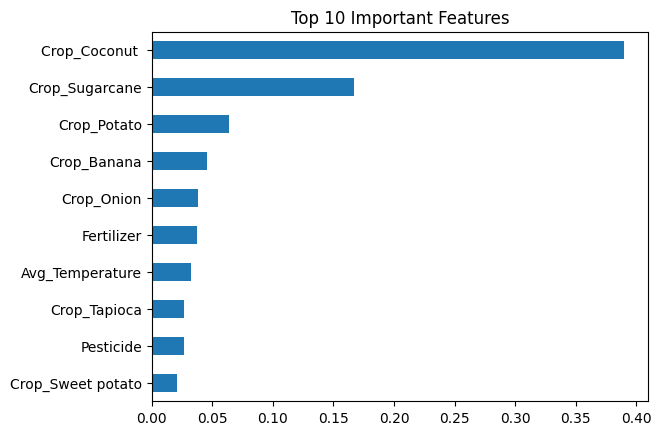

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

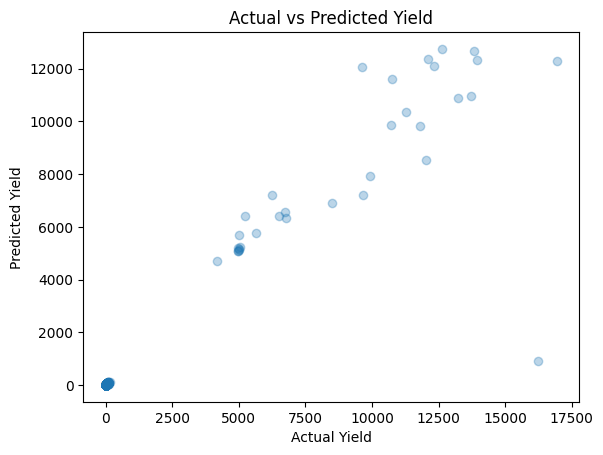

In [13]:
plt.scatter(y_test_original, y_pred, alpha=0.3)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.show()

In [14]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    model, X, y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross-validation R2 scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))

Cross-validation R2 scores: [0.96089815 0.93713645 0.90706878 0.90644802 0.88646289]
Mean CV R2: 0.9196028578466262


In [15]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train R2: 0.9934459294583334
Test R2: 0.9651274639395854


In [16]:
import joblib
joblib.dump(model, "crop_yield_rf_model.pkl")

['crop_yield_rf_model.pkl']

In [17]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_log_xgb = xgb.predict(X_test)
y_pred_xgb = np.expm1(y_pred_log_xgb)

from sklearn.metrics import r2_score
print("XGB R2:", r2_score(y_test_original, y_pred_xgb))

XGB R2: 0.9384420530844403


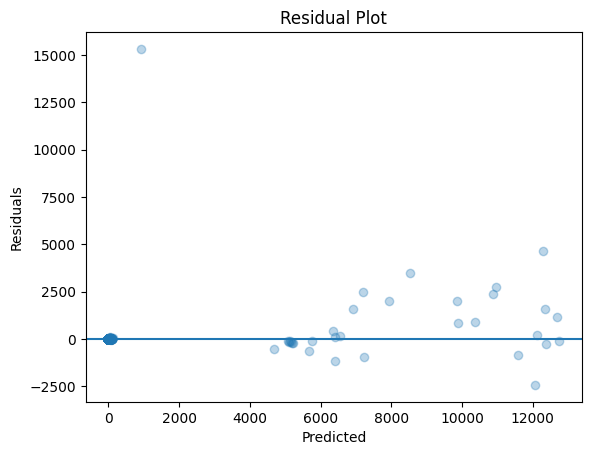

In [18]:
import matplotlib.pyplot as plt

residuals = y_test_original - y_pred

plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [19]:
import joblib

model = joblib.load("crop_yield_rf_model.pkl")
print("Model loaded successfully!")

Model loaded successfully!


In [21]:
print(df["State"].unique())

['Assam' 'Karnataka' 'Kerala' 'Meghalaya' 'West Bengal' 'Puducherry' 'Goa'
 'Andhra Pradesh' 'Tamil Nadu' 'Odisha' 'Bihar' 'Gujarat' 'Madhya Pradesh'
 'Maharashtra' 'Mizoram' 'Punjab' 'Uttar Pradesh' 'Haryana'
 'Himachal Pradesh' 'Tripura' 'Nagaland' 'Chhattisgarh' 'Uttarakhand'
 'Jharkhand' 'Delhi' 'Manipur' 'Jammu and Kashmir' 'Telangana'
 'Arunachal Pradesh' 'Sikkim']


In [22]:
print(df["Crop"].unique())

['Arecanut' 'Arhar/Tur' 'Castor seed' 'Coconut ' 'Cotton(lint)'
 'Dry chillies' 'Gram' 'Jute' 'Linseed' 'Maize' 'Mesta' 'Niger seed'
 'Onion' 'Other  Rabi pulses' 'Potato' 'Rapeseed &Mustard' 'Rice'
 'Sesamum' 'Small millets' 'Sugarcane' 'Sweet potato' 'Tapioca' 'Tobacco'
 'Turmeric' 'Wheat' 'Bajra' 'Black pepper' 'Cardamom' 'Coriander' 'Garlic'
 'Ginger' 'Groundnut' 'Horse-gram' 'Jowar' 'Ragi' 'Cashewnut' 'Banana'
 'Soyabean' 'Barley' 'Khesari' 'Masoor' 'Moong(Green Gram)'
 'Other Kharif pulses' 'Safflower' 'Sannhamp' 'Sunflower' 'Urad'
 'Peas & beans (Pulses)' 'other oilseeds' 'Other Cereals' 'Cowpea(Lobia)'
 'Oilseeds total' 'Guar seed' 'Other Summer Pulses' 'Moth']


In [24]:
df[df["Crop"] == "Gram"]["Yield"].describe()

count    490.000000
mean       0.606565
std        0.195427
min        0.000000
25%        0.470004
50%        0.598012
75%        0.705940
max        2.339881
Name: Yield, dtype: float64